:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_03_1D_convolution.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(convolution_background)=
# Convolution

## Generate synthetic data
Generate some simulated spike counts.

In [2]:
import matplotlib.patches as patches
import matplotlib.pylab as plt
import numpy as np

import nemos as nmo

np.random.seed(10)
ws = 10
# samples
n_samples = 100

spk = np.random.poisson(lam=0.1, size=(n_samples, ))

# add borders (extreme case, general border effect are represented)
spk[0] = 1
spk[3] = 1
spk[-1] = 1
spk[-4] = 1

## Causal, Anti-Causal, and Acausal Predictors

To construct a temporal predictor with a specified causality, we convolve a time series with one or more filters using `"valid"` mode, then pad the result according to the desired direction of causality—causal, anti-causal, or acausal.

:::{note}
The `"valid"` mode of convolution only calculates the product when the two input vectors overlap completely,
avoiding border artifacts. The outcome of such a convolution will
be an array of `max(M,N) - min(M,N) + 1` elements in length, where `M` and `N` represent the number
of elements in the arrays being convolved. For more detailed information on this,
see [jax.numpy.convolve](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.convolve.html).
:::

A causal filter captures how an event or task variable influences the future firing-rate.
An example usage case would be that of characterizing the refractory period of a neuron
(i.e. the drop in firing rate  immediately after a spike event). Another example could be characterizing how
the current position of an animal in a maze would affect its future spiking activity.

On the other hand, if we are interested in capturing the firing rate modulation before an event occurs we may want
to use an anti-causal filter. An example of that may be the preparatory activity of pre-motor cortex that happens
before a movement is initiated (here the event is. "movement onset").

Finally, if one wants to capture both causal
and anti-causal effects one should use the acausal filters.
Below we provide the function [`create_convolutional_predictor`](nemos.convolve.create_convolutional_predictor) that runs the convolution in "valid" mode and pads the convolution output
for the different filter types.

In [3]:
# create three filters
basis_obj = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=3)
_, w = basis_obj.evaluate_on_grid(ws)

# pad according to the causal direction of the filter, after squeeze,
# the dimension is (n_filters, n_samples)
spk_causal_conv = nmo.convolve.create_convolutional_predictor(
        w, spk, predictor_causality="causal"
)
spk_anticausal_conv = nmo.convolve.create_convolutional_predictor(
        w, spk, predictor_causality="anti-causal"
)
spk_acausal_conv = nmo.convolve.create_convolutional_predictor(
        w, spk, predictor_causality="acausal"
)

/home/jenkins/agent/workspace/CCN_nemos_main/venv/lib/python3.12/site-packages/nemos/convolve.py:678: UserWarning: With `acausal` filter, `basis_matrix.shape[0] should probably be odd, so that we can place an equal number of NaNs on either side of input.
  warnings.warn(


Plot the results

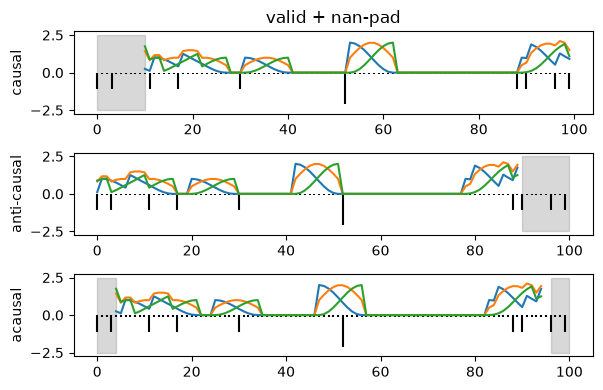

In [4]:
# NaN padded area
rect_causal = patches.Rectangle((0, -2.5), ws, 5, alpha=0.3, color='grey')
rect_anticausal = patches.Rectangle((len(spk)-ws, -2.5), ws, 5, alpha=0.3, color='grey')
rect_acausal_left = patches.Rectangle((0, -2.5), (ws-1)//2, 5, alpha=0.3, color='grey')
rect_acausal_right = patches.Rectangle((len(spk) - (ws-1)//2, -2.5), (ws-1)//2, 5, alpha=0.3, color='grey')

# Set this figure as the thumbnail
# mkdocs_gallery_thumbnail_number = 2

fig = plt.figure(figsize=(6, 4))

shift_spk = - spk - 0.1
ax = plt.subplot(311)

plt.title('valid + nan-pad')
ax.add_patch(rect_causal)
plt.vlines(np.arange(spk.shape[0]), 0, shift_spk, color='k')
plt.plot(np.arange(spk.shape[0]), spk_causal_conv)
plt.ylabel('causal')

ax = plt.subplot(312)
ax.add_patch(rect_anticausal)
plt.vlines(np.arange(spk.shape[0]), 0, shift_spk, color='k')
plt.plot(np.arange(spk.shape[0]), spk_anticausal_conv)
plt.ylabel('anti-causal')

ax = plt.subplot(313)
ax.add_patch(rect_acausal_left)
ax.add_patch(rect_acausal_right)
plt.vlines(np.arange(spk.shape[0]), 0, shift_spk, color='k')
plt.plot(np.arange(spk.shape[0]), spk_acausal_conv)
plt.ylabel('acausal')
plt.tight_layout()

In [5]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/background"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/background")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_03_1D_convolution.svg")

## Convolve using [`Basis.compute_features`](nemos.basis._basis.Basis.compute_features)

Every basis in the `nemos.basis` module whose class name ends with "Conv" will perform a 1D convolution over the
provided input when the `compute_features` method is called. The basis elements will be used as filters for the
convolution.

All the parameters of [`create_convolutional_predictor`](nemos.convolve.create_convolutional_predictor) can be passed to the object directly at initialization.
Let's see how we can get the same results through [`Basis`](nemos.basis._basis.Basis).

In [6]:
# define basis with different predictor causality
causal_basis = nmo.basis.RaisedCosineLinearConv(
        n_basis_funcs=3, window_size=ws,
        conv_kwargs=dict(predictor_causality="causal")

)

acausal_basis = nmo.basis.RaisedCosineLinearConv(
        n_basis_funcs=3, window_size=ws,
        conv_kwargs=dict(predictor_causality="acausal")
)

anticausal_basis = nmo.basis.RaisedCosineLinearConv(
        n_basis_funcs=3, window_size=ws,
        conv_kwargs=dict(predictor_causality="anti-causal")
)

# compute convolutions
basis_causal_conv = causal_basis.compute_features(spk)
basis_acausal_conv = acausal_basis.compute_features(spk)
basis_anticausal_conv = anticausal_basis.compute_features(spk)

/home/jenkins/agent/workspace/CCN_nemos_main/venv/lib/python3.12/site-packages/nemos/convolve.py:678: UserWarning: With `acausal` filter, `basis_matrix.shape[0] should probably be odd, so that we can place an equal number of NaNs on either side of input.
  warnings.warn(
